In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

# Load datasets

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [2]:
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)
print(performance.shape)
print(transactions.shape)
print(holdings.shape)
print(benchmark.shape)

(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(40, 19)
(32778, 13)
(322, 8)
(8050, 3)


In [3]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Merge with scheme names
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Create interactive line chart
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

In [6]:
import sys
print(sys.executable)

c:\Users\user\AppData\Local\Programs\Python\Python313\python.exe


In [8]:
import sys
print(sys.executable)

c:\Users\user\AppData\Local\Programs\Python\Python313\python.exe


In [9]:
import plotly
print(plotly.__version__)

6.1.2


In [11]:
import plotly.io as pio

pio.write_image(
    fig,
    "../reports/charts/nav_trend_analysis.png"
)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [12]:
import sys
print(sys.executable)

c:\Users\user\AppData\Local\Programs\Python\Python313\python.exe


In [1]:
import plotly.io as pio

print("Kaleido scope:", pio.kaleido.scope)

Kaleido scope: <plotly.io._kaleido.DefaultsWrapper object at 0x000002B7A08D8590>


In [4]:
import pandas as pd

# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"] )

# Create Year column
aum["year"] = aum["date"].dt.year

# Aggregate AUM by fund house and year
aum_year = (
    aum.groupby(["year", "fund_house"], as_index=False)["aum_lakh_crore"]
    .mean()
)

aum_year.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765


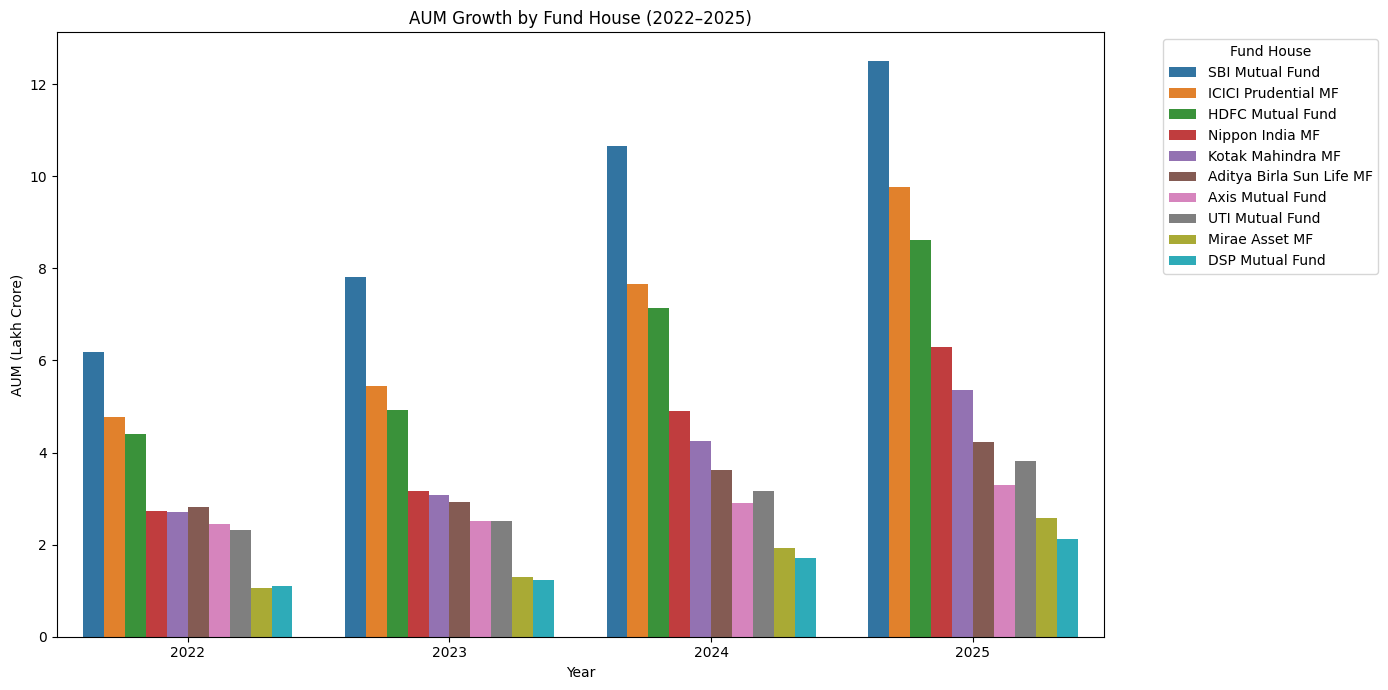

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create year column (if not already created)
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    estimator="mean",
    errorbar=None
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Text(3, 12.5, 'SBI Peak ≈ ₹12.5L Cr')

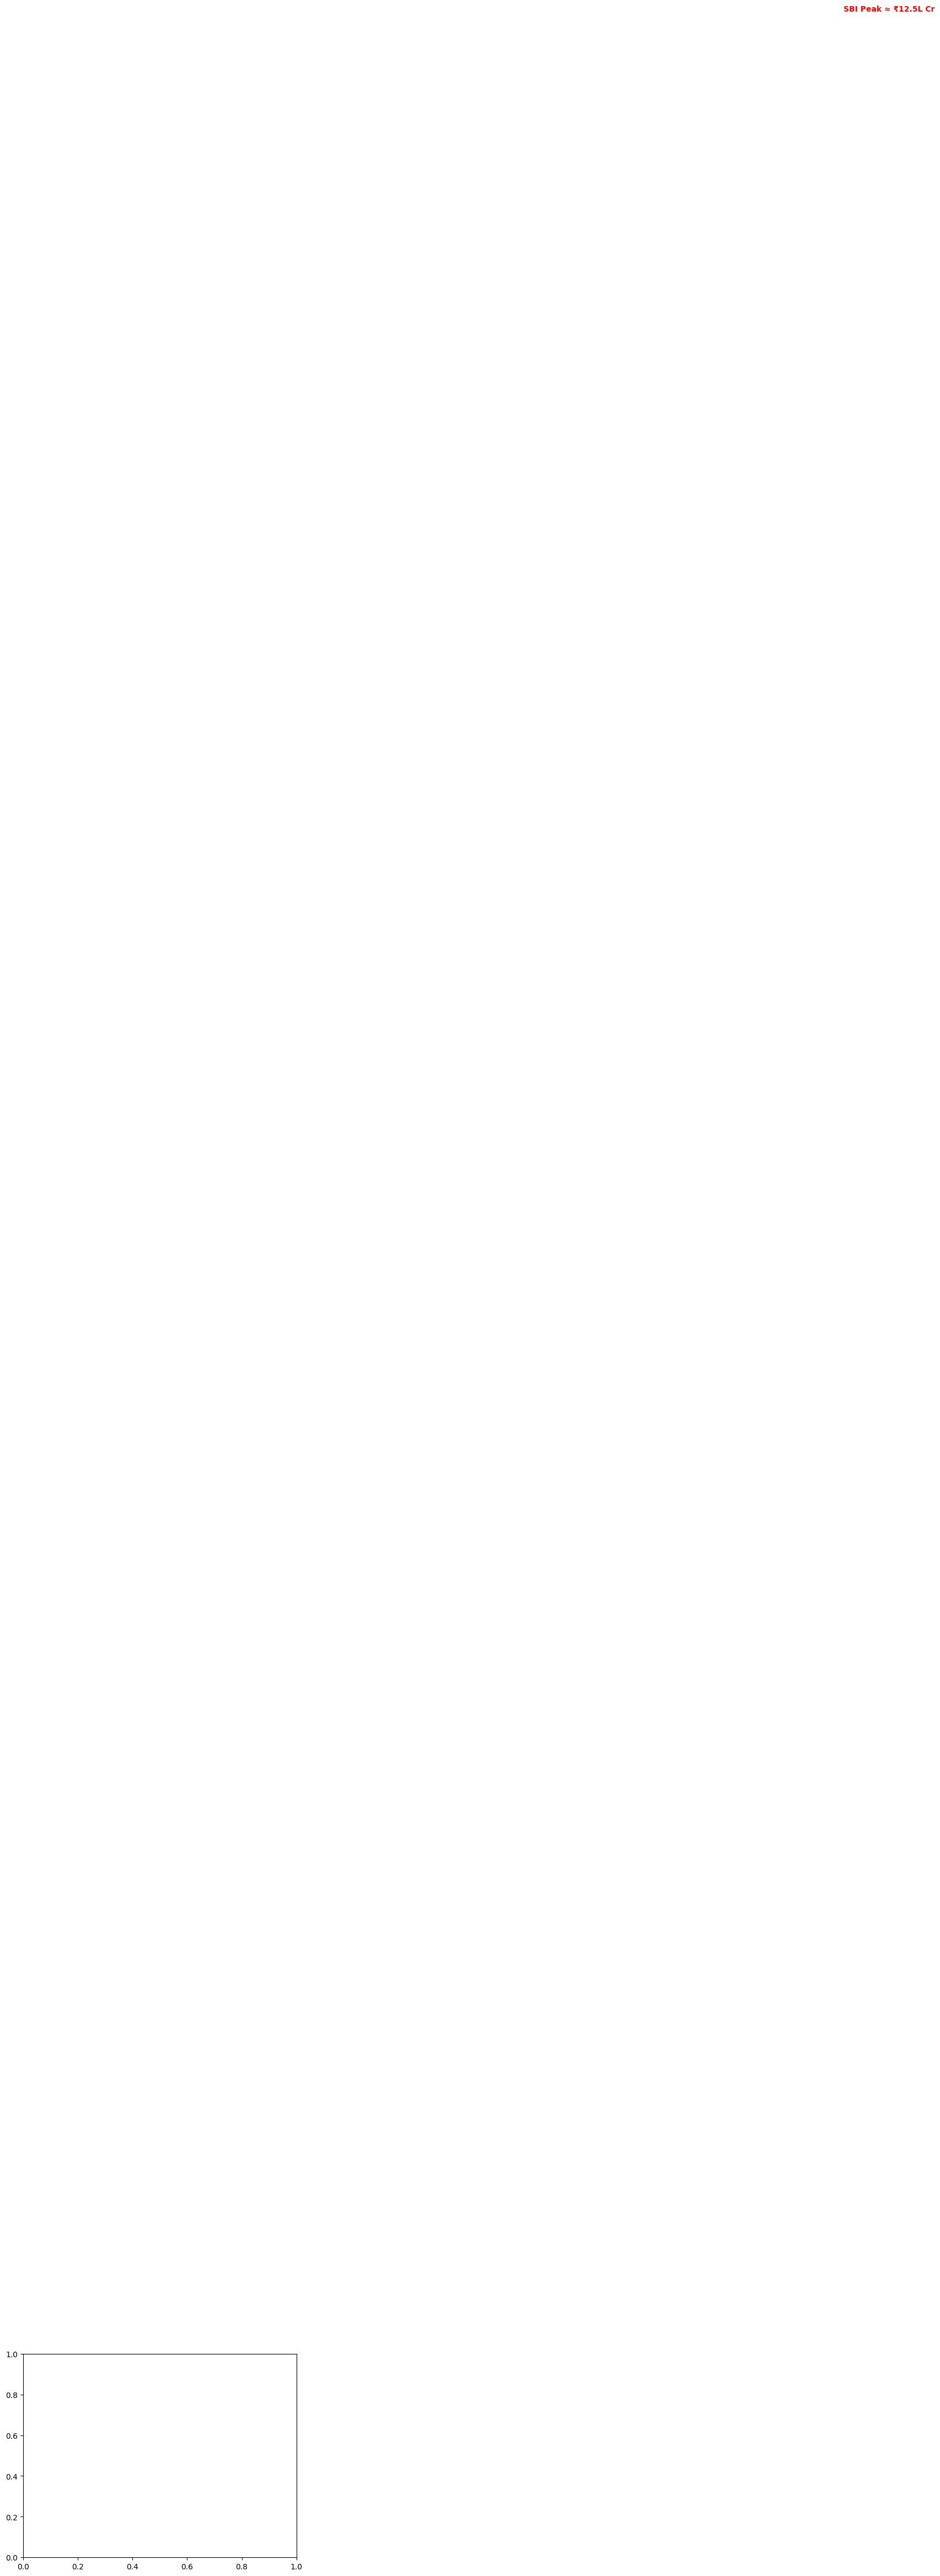

In [ ]:
plt.text(
    3,
                "if state_sip.empty:",
                "    print(\"No SIP records with state data were found, so the state chart cannot be generated.\")",
                "else:",
                "    state_sip.plot(kind=\"barh\")",
                "    plt.title(\"Total SIP Amount by State\")",
                "    plt.xlabel(\"Total SIP Amount (₹)\")",
                "    plt.ylabel(\"State\")",
                "    plt.tight_layout()",
                "    plt.savefig(",
                "        \"../reports/charts/sip_amount_by_state.png\",",
                "        dpi=300,",
                "        bbox_inches=\"tight\"",
                "    )",
                "    plt.show()"
    estimator="mean",
    errorbar=None,
    ax=ax
)

ax.set_title("AUM Growth by Fund House (2022–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("AUM (Lakh Crore)")

plt.tight_layout()

fig.savefig(
    "../reports/charts/aum_growth_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [10]:
print(aum_year.head())
print(aum_year.shape)

   year                fund_house  aum_lakh_crore
0  2022  Aditya Birla Sun Life MF           2.815
1  2022          Axis Mutual Fund           2.450
2  2022           DSP Mutual Fund           1.110
3  2022          HDFC Mutual Fund           4.400
4  2022       ICICI Prudential MF           4.765
(40, 3)


In [11]:
print(aum["date"].dtype)
print(aum["year"].unique())

datetime64[ns]
[2022 2023 2024 2025]


In [12]:
print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [13]:
aum_year = (
    aum.groupby(["year", "fund_house"], as_index=False)["aum_lakh_crore"]
    .mean()
)

print(aum_year.head(20))
print(aum_year.shape)

    year                fund_house  aum_lakh_crore
0   2022  Aditya Birla Sun Life MF           2.815
1   2022          Axis Mutual Fund           2.450
2   2022           DSP Mutual Fund           1.110
3   2022          HDFC Mutual Fund           4.400
4   2022       ICICI Prudential MF           4.765
5   2022         Kotak Mahindra MF           2.710
6   2022            Mirae Asset MF           1.065
7   2022           Nippon India MF           2.740
8   2022           SBI Mutual Fund           6.175
9   2022           UTI Mutual Fund           2.310
10  2023  Aditya Birla Sun Life MF           2.915
11  2023          Axis Mutual Fund           2.505
12  2023           DSP Mutual Fund           1.235
13  2023          HDFC Mutual Fund           4.925
14  2023       ICICI Prudential MF           5.450
15  2023         Kotak Mahindra MF           3.070
16  2023            Mirae Asset MF           1.290
17  2023           Nippon India MF           3.165
18  2023           SBI Mutual F

In [22]:
# Convert month to datetime and make values JSON-serializable for export
sip["month"] = pd.to_datetime(sip["month"]).dt.to_pydatetime()

# Create interactive line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

C:\Users\user\AppData\Local\Temp\ipykernel_15072\2644967805.py:2: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  sip["month"] = pd.to_datetime(sip["month"]).dt.to_pydatetime()


In [18]:
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [23]:
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
peak_month = pd.to_datetime(peak["month"]).to_pydatetime()

fig.add_annotation(
    x=peak_month,
    y=peak["sip_inflow_crore"],
    text=f"Peak: ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [24]:
fig.write_image("../reports/charts/sip_inflow_trend.png")

In [25]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create a month-year label
category["month_label"] = category["month"].dt.strftime("%b-%Y")

In [26]:
heatmap_data = category.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

heatmap_data.head()

month_label,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


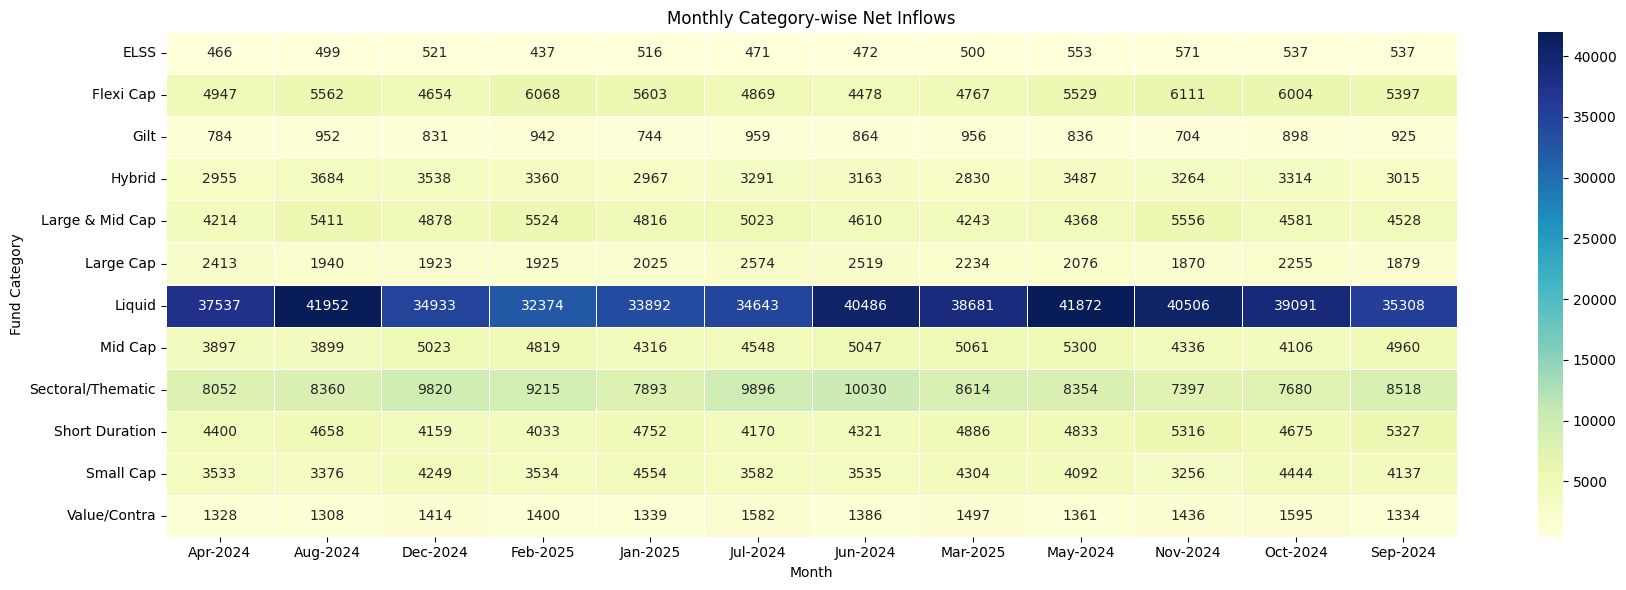

In [27]:
plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Category-wise Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

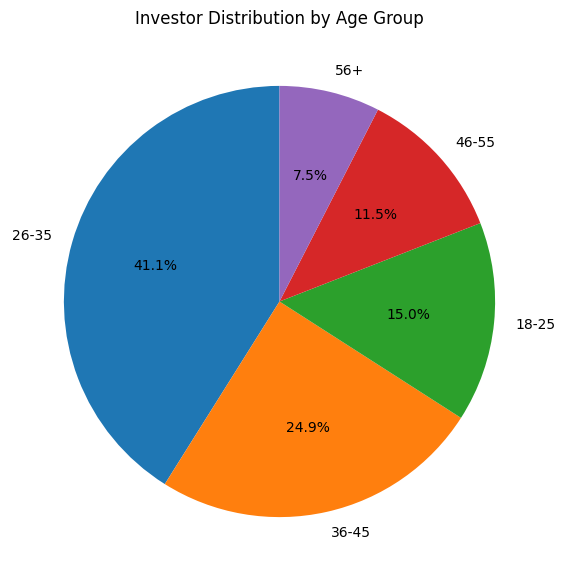

In [28]:
# Count investors by age group
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.savefig(
    "../reports/charts/investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
sip_txn = transactions[
    transactions["transaction_type"] == "SIP"
]

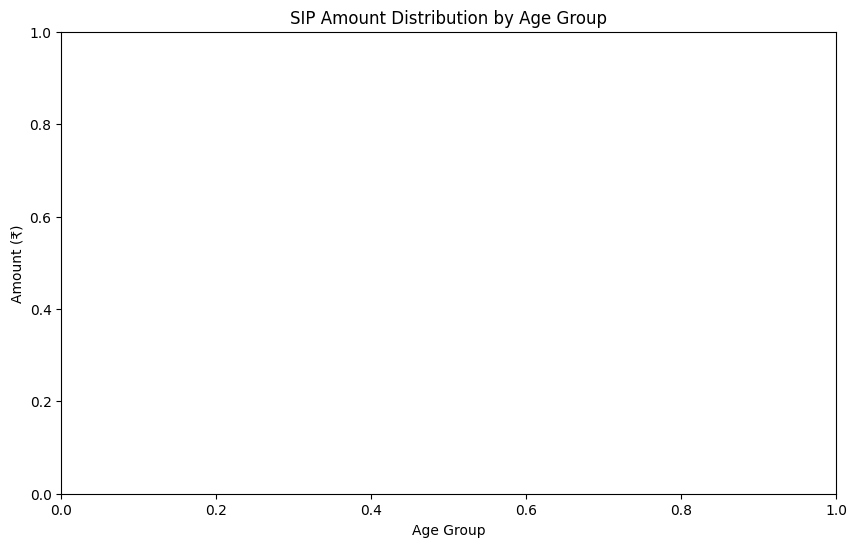

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (₹)")

plt.savefig(
    "../reports/charts/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

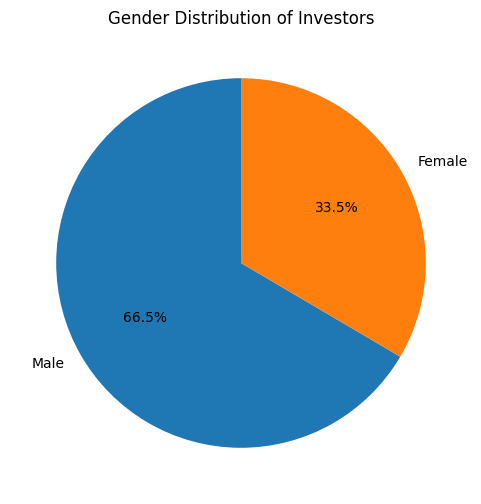

In [31]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Filter only SIP transactions
sip_state = transactions[transactions["transaction_type"] == "SIP"]

# Total SIP amount by state
state_sip = (
    sip_state.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

state_sip.head()

Series([], Name: amount_inr, dtype: int64)

In [39]:
plt.figure(figsize=(10,8))

if state_sip.empty:
    print("No SIP records with state data were found, so the state chart cannot be generated.")
else:
    state_sip.plot(kind="barh")
    plt.title("Total SIP Amount by State")
    plt.xlabel("Total SIP Amount (₹)")
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig(
        "../reports/charts/sip_amount_by_state.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

No SIP records with state data were found, so the state chart cannot be generated.


<Figure size 1000x800 with 0 Axes>

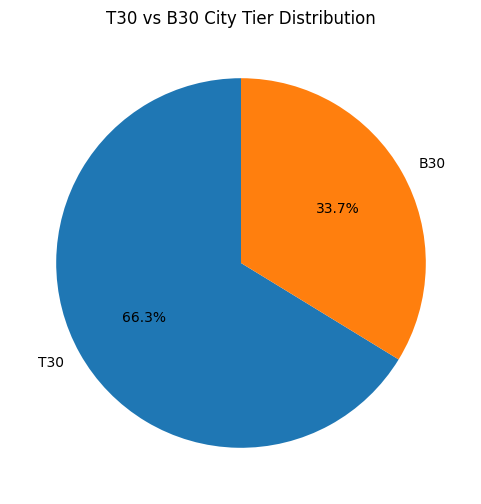

In [40]:
city_tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig(
    "../reports/charts/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])
folio = folio.sort_values("month").copy()
folio["month"] = folio["month"].dt.strftime("%Y-%m-%d")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [47]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folio Count (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

In [48]:
first = folio.iloc[0]
last = folio.iloc[-1]

fig.add_annotation(
    x=first["month"],
    y=first["total_folios_crore"],
    text=f"Start: {first['total_folios_crore']} Cr",
    showarrow=True,
    arrowhead=2
)

fig.add_annotation(
    x=last["month"],
    y=last["total_folios_crore"],
    text=f"End: {last['total_folios_crore']} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [49]:
fig.write_image("../reports/charts/folio_count_growth.png")

In [50]:
# Select first 10 schemes
selected_funds = fund_master["amfi_code"].unique()[:10]

selected_funds

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [51]:
nav_selected = nav[nav["amfi_code"].isin(selected_funds)].copy()

nav_selected.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [52]:
nav_pivot = nav_selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [53]:
returns = nav_pivot.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660
2022-01-10,-0.008639,0.006791,0.006277,-0.000353,-0.001548,0.009465,0.051113,0.033761,0.003057,-0.019536


In [54]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


In [55]:
name_map = fund_master.set_index("amfi_code")["scheme_name"]

corr_matrix.columns = [
    name_map[x] for x in corr_matrix.columns
]

corr_matrix.index = corr_matrix.columns

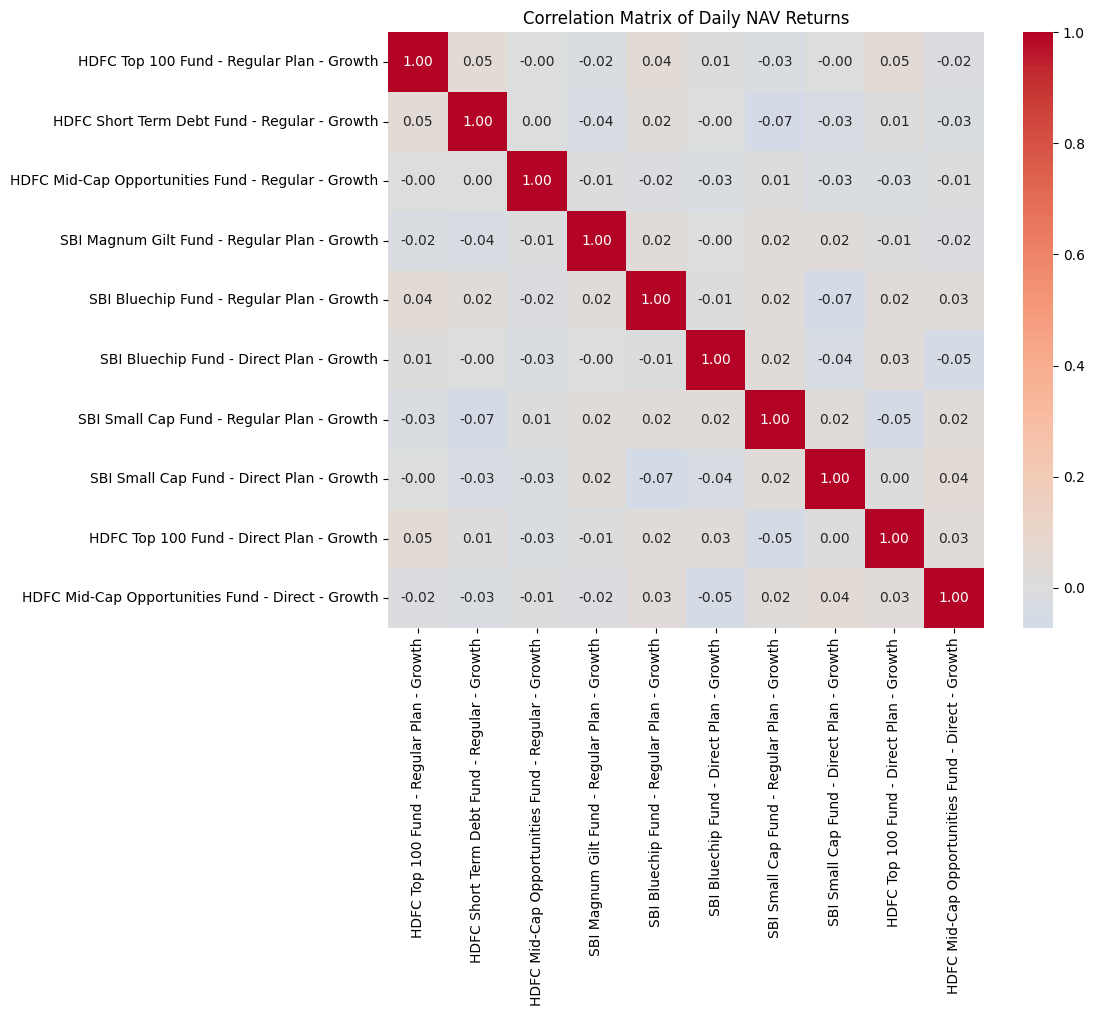

In [56]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
# Merge holdings with fund information
sector_data = holdings.merge(
    fund_master[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

# Keep only Equity funds
sector_data = sector_data[sector_data["category"] == "Equity"]

sector_data.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,category
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,Equity
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,Equity
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,Equity
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,Equity
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,Equity


In [58]:
sector_weights = (
    sector_data.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [59]:
fig = px.pie(
    names=sector_weights.index,
    values=sector_weights.values,
    title="Sector Allocation Across Equity Funds",
    hole=0.45
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.update_layout(
    template="plotly_white",
    height=650
)

fig.show()

In [60]:
fig.write_image("../reports/charts/sector_allocation_donut.png")

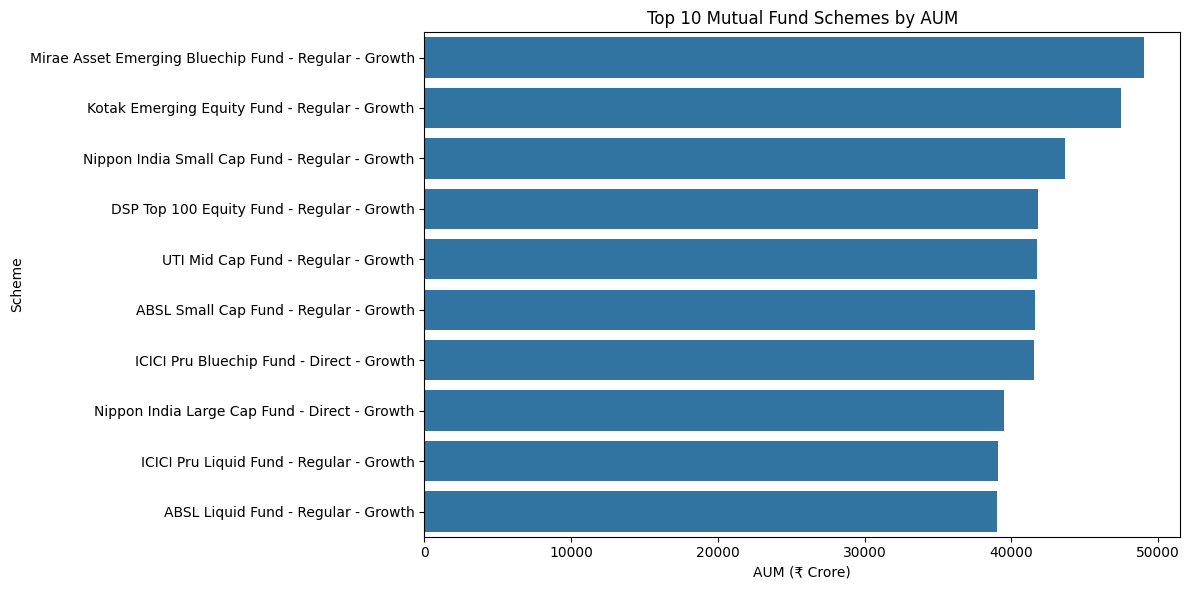

In [61]:
# Top 10 schemes by AUM
top_aum = performance.sort_values(
    by="aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Fund Schemes by AUM")
plt.xlabel("AUM (₹ Crore)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_funds_by_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

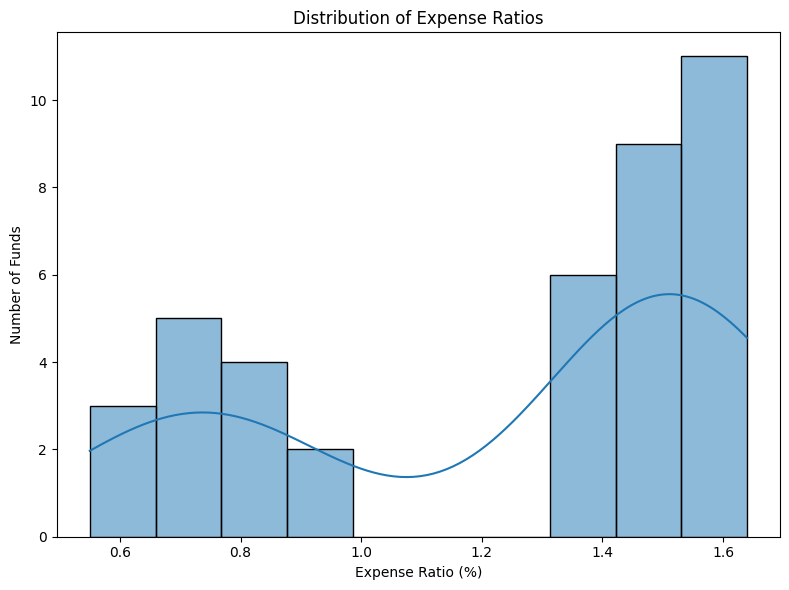

In [62]:
plt.figure(figsize=(8,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Distribution of Expense Ratios")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    "../reports/charts/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

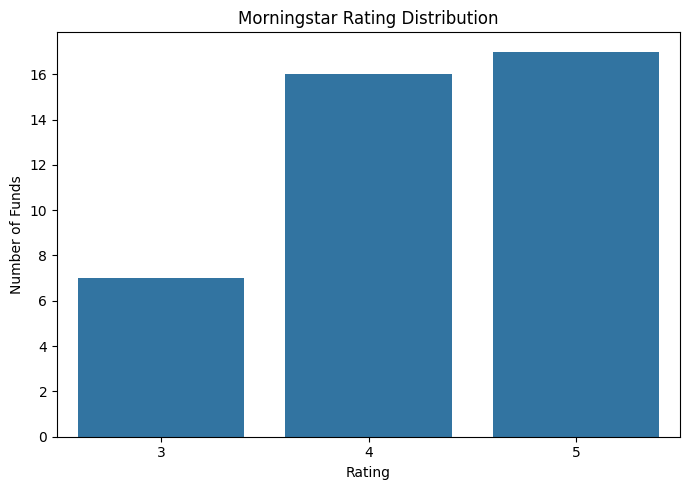

In [63]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig(
    "../reports/charts/morningstar_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()